# Intro to Latent Variable Models and Pollux model classes

In [ ]:
import daft
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import numpyro.distributions as dist

import pollux as plx
from pollux.models.transforms import LinearTransform

rng = np.random.default_rng(42)

Latent Variable Models (LVMs) are a general class of models that are useful for many types of problems. For the purposes of Pollux and this note, LVMs are generative models of data in which some of the variables are unobserved (i.e. *latent*) and some are noisily observed. More specifically within Pollux, we split the latent parameters of a model into two conceptual classes: we refer to vector-valued, per-object latent variables as _the latents_ and all other (even latent) parameters are the _coefficients_ or parameters of the model. This distinction might seem arbitrary, but the point is that _the latents_ scale with the number of objects in the dataset whereas the _coefficients_ do not. In this context, _the latents_ are often used to capture (or discover) structure in the data and are sometimes interpretable. These types of generative models are related to machine learning methods and concepts like [embeddings](https://en.wikipedia.org/wiki/Embedding_(machine_learning)), [representation learning](https://en.wikipedia.org/wiki/Representation_learning), and [autoencoders](https://en.wikipedia.org/wiki/Variational_autoencoder).

A general [probabilistic graphical model](https://adrian.pw/blog/probabilistic-graphical-models/) (PGM) for a latent variable model of the form used throughout Pollux is shown below:

/Users/aprice-whelan/projects/pollux/.venv/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  func(*args, **kwargs)
/Users/aprice-whelan/projects/pollux/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.canvas.print_figure(bytes_io, **kw)


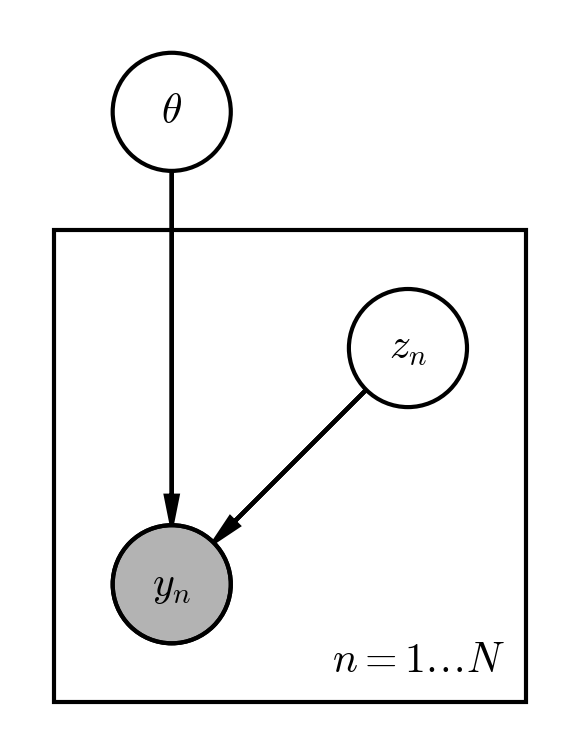

In [2]:
pgm = daft.PGM(observed_style="shaded", dpi=150)
pgm.add_node("theta", r"$\theta$", 1, 3)
pgm.add_node("z", r"$z_n$", 2, 2)
pgm.add_node("y", r"$y_n$", 1, 1, observed=True)
for parent, child in [("z", "y"), ("theta", "y")]:
    pgm.add_edge(parent, child)
pgm.add_plate(
    [0.5, 0.5, 2.0, 2.0], label=r"$n = 1 \ldots N$", shift=0.0, position="bottom right"
)
pgm.render();

In the PGM above, $y_n$ are the observed data for object index $n$, $z_n$ are the latent variables for object index $n$, and $\theta$ are the coefficients of the model. (Remember that PGMs do not show the functional form of the model, only the conditional dependencies between the variables, so we still haven't specified how $\theta$ and $z_n$ combine to produce $y_n$.) The plate indicates that there are $N$ objects in the dataset, each with its own latent variable(s) $z_n$ and observed data $y_n$. In general, $y$ and $z$ are vector valued and $\theta$ may be an arbitrarily-shaped tensor.

This is a very general model structure, and many models you may be familiar with can be thought of as special cases of a general LVM. For example: 
- Principal component analysis (PCA) -- specifically probabilistic PCA -- can be interpreted as an LVM in which the latents are the coefficients of the principal components and $\theta$ are the principal component vectors. (Or, more generally than pPCA, factor analysis is an LVM in which the latents are the coefficients of the factors and $\theta$ are the factors).
- Linear regression can be thought of as (degenerate form of) a LVM in which the latents are the true (noiseless) values of $y_n$ and the coefficients $\theta$ as the vector of linear parameters (e.g., slope and intercept). In this case, at fixed $\theta$ and covariates, each $z_n$ is determined rather than uncertain, so the per-object latents aren't actually free parameters.
- Gaussian mixture models (GMMs) are an example of an LVM where some latents are discrete: in a GMM, each $z_n$ is a discrete assignment of object $n$ to one of $K$ components, whereas the coefficients $\theta$ are the means, covariances, and mixing weights of those components.
- Various data-driven stellar spectroscopy models (e.g., _The Cannon_, _Lux_) are also LVMs. In this case, the data are the observed spectra of stars and the latents are either fixed to (a transformation of) the stellar labels (effective temperature, surface gravity, chemical abundances, etc. in the case of _The Cannon_) or left free (in the case of _Lux_). The coefficients describe how the flux at each wavelength responds to the latents, and are shared across every star in the survey. 

At this point you might be wondering: are all probabilistic models LVMs? The answer is that many (or most) generative models can be written in the form of an LVM, but it is useful to think of a model as an LVM depends on the context. For example, it is not particularly useful to think of standard linear regression model as an LVM, but fitting a linear model with uncertainties on both $x$ and $y$ and with missing or censored data might be useful to structure as an LVM.

Let's look at some more concrete examples.

## A linear model as a simple LVM

The PGM above does not define the functional form of the model or relationships between the latents and outputs (data). For this example, we'll use a linear model to make some of these concepts more concrete. For this model:
$$
\boldsymbol{y} = \boldsymbol{\mathrm{A}} \, \boldsymbol{z} + \mathrm{noise}
$$
where $z$ is a $L=3$ dimensional latent space, $y$ is a $D=128$ dimensional data vector, and therefore the matrix $\mathrm{A}$ is a $(D, L) = (128, 3)$ dimensional mapping from latents to data. For example, imagine that the data $y$ is a spectrum with 128 pixels and the latents represent some intrinsic properties of the sources. Because this is a linear model, the columns of $\mathrm{A}$ are often called basis vectors and the corresponding latent values are the basis weights, but in our terminology $z$ are _the latents_ and the elements of $\mathrm{A}$ are _the coefficients_.

Let's make some simulated data with this structure for $N=512$ objects. We'll put in three basis vectors to the columns of $A$ to make the simulated data more visually interesting (inspired by absorption lines in a stellar spectrum):

In [44]:
N = 512
D = 128
L = 3

rng = np.random.default_rng(123)

A = np.zeros((D, L))
pix = np.arange(D)
A[:, 0] = np.exp(-0.5 * (pix - 64) ** 2 / 10**2)
A[:, 1] = np.exp(-0.5 * (pix - 32) ** 2 / 2**2)
A[:, 2] = np.exp(-0.5 * (pix - 96) ** 2 / 5**2)

z = -np.abs(rng.normal(size=(N, L)))
true_y = z @ A.T

# heteroskedastic noise
y_err = 10 ** (rng.uniform(-1., 0.5, size=(N, D)))

y = true_y + rng.normal(scale=y_err)

Here are the true basis vectors:

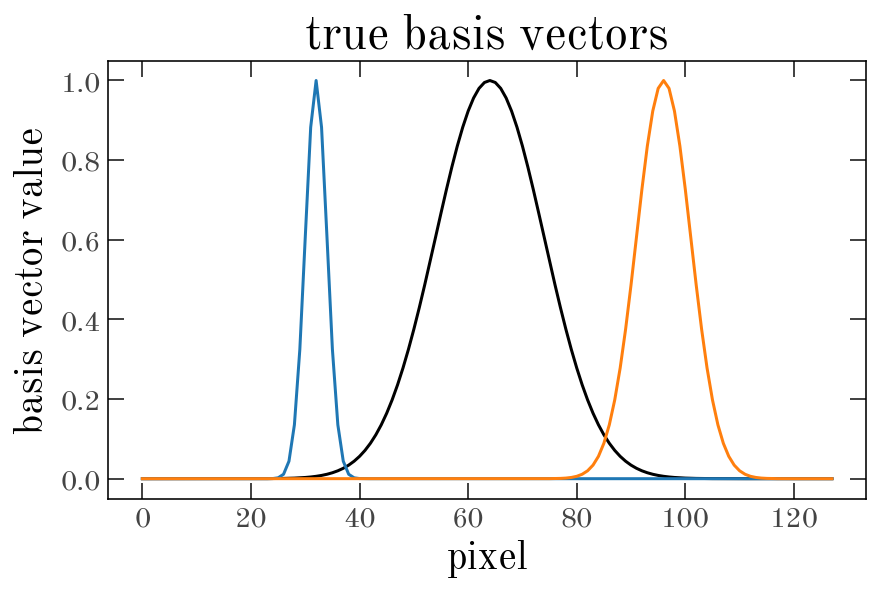

In [45]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.plot(A, marker="")
_ = ax.set(xlabel="pixel", ylabel="basis vector value", title="true basis vectors")

And now some of the simulated data (the first 4 objects) with error bars. Notice that the data are quite noisy:

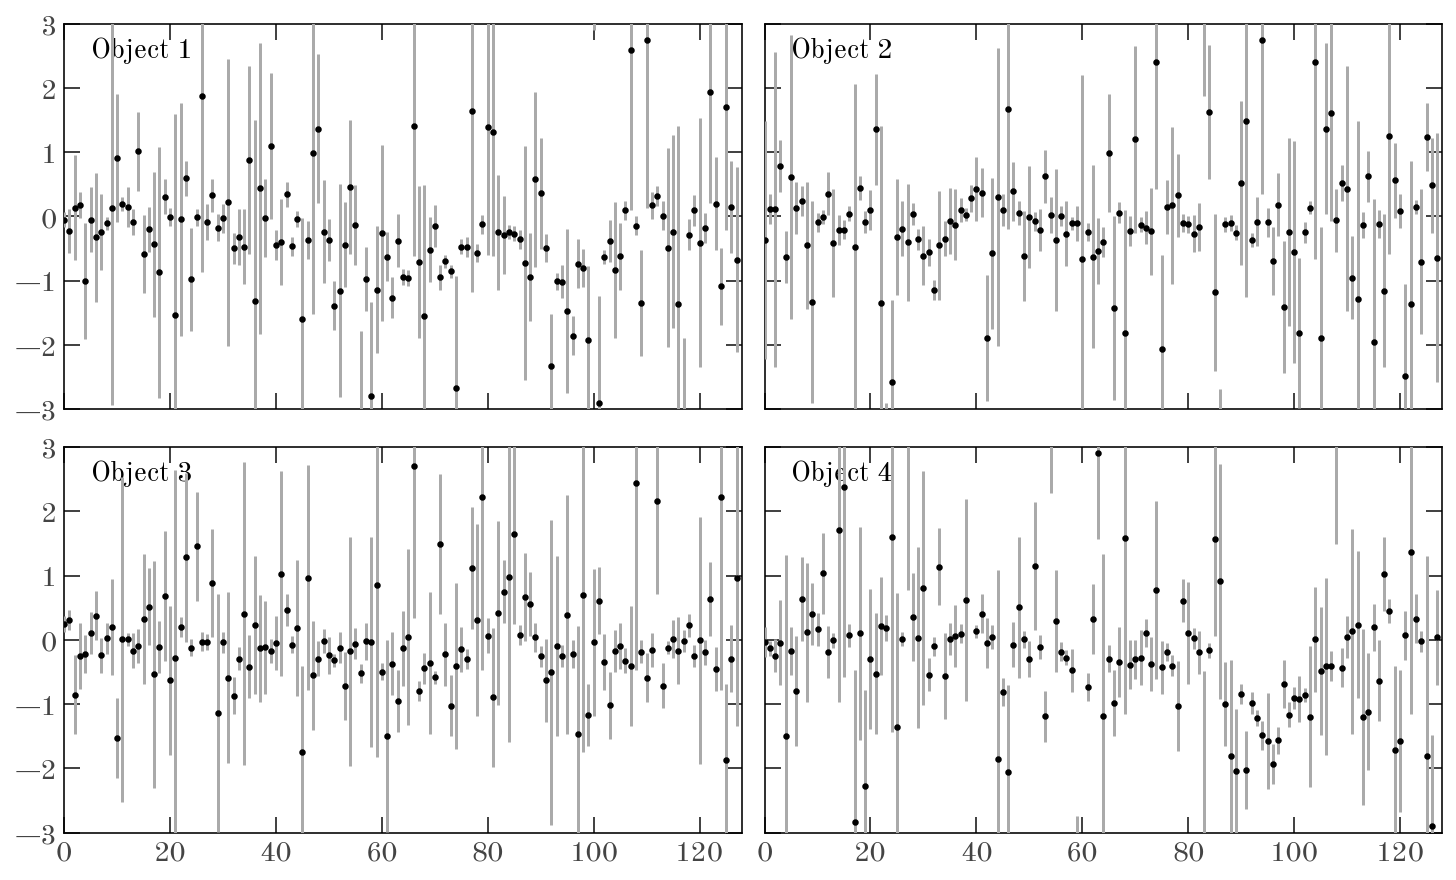

In [46]:
fig, axes = plt.subplots(
    2, 2, figsize=(10, 6), layout="constrained", sharex=True, sharey=True
)
for i in range(4):
    ax = axes.flat[i]
    ax.scatter(pix, y[i], marker="o", s=5, color="k", zorder=10)
    ax.errorbar(
        pix, y[i], yerr=y_err[i], marker="none", color="#aaaaaa", zorder=5, ls="none"
    )
    ax.set(xlim=(0, D), ylim=(-3, 3))
    ax.text(5, 2.8, f"Object {i + 1}", ha="left", va="top", fontsize=14)

If there was no measurement uncertainty, we could recover (a linear combination of) the basis vectors using a standard singular value decomposition (SVD): in the Figure below, the left panel shows the SVD of the true $y$ values, demonstrating that there is a huge drop off in power after 3 components, indicating that the data can be well decomposed into a combination of three basis vectors. The right panel of the Figure shows the SVD of the noisy data --- here there is a more "flat" distribution of singular values because of the heteroskedastic noise. 

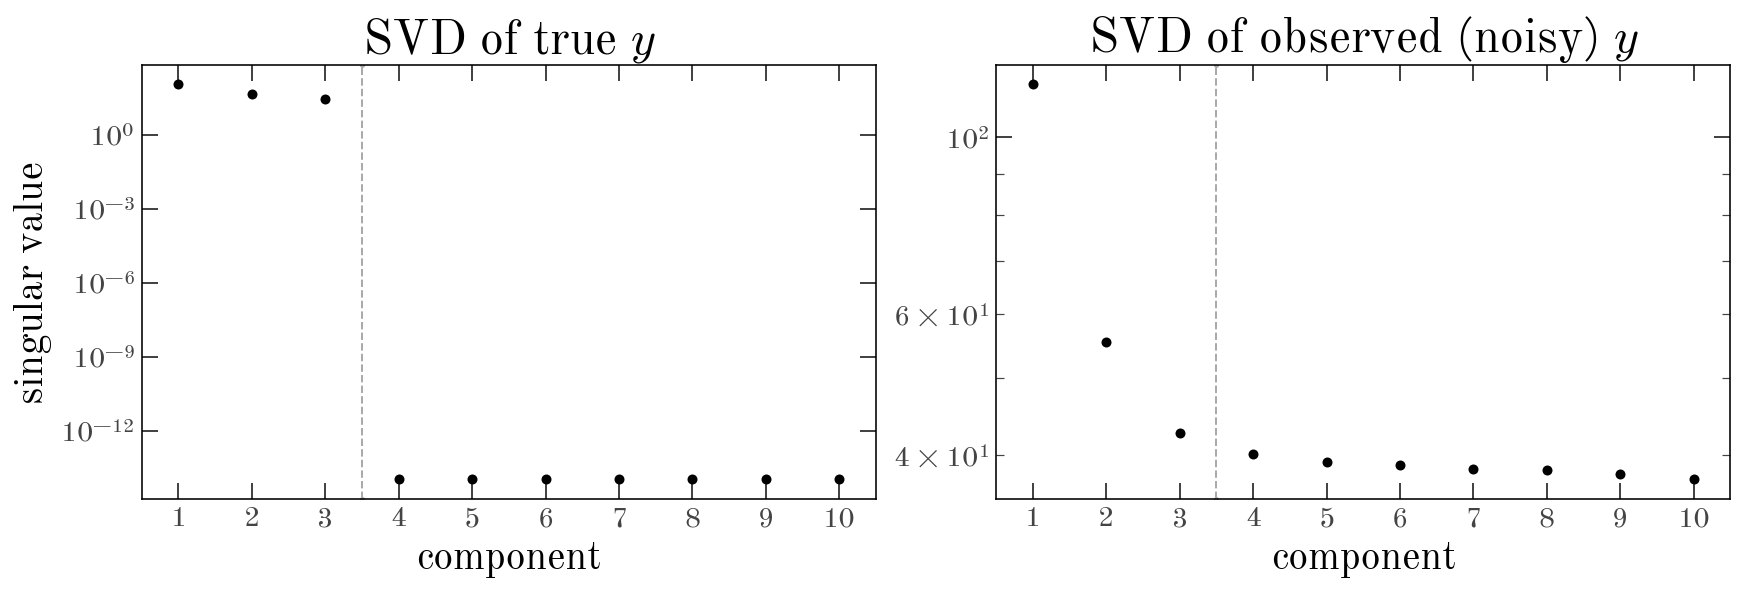

In [47]:
true_svd = np.linalg.svd(true_y, compute_uv=True)
err_svd = np.linalg.svd(y, compute_uv=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), layout="constrained", sharex=True)
names = ["SVD of true $y$", "SVD of observed (noisy) $y$"]
axes[0].plot(
    np.arange(1, 11),
    true_svd.S[:10],
    marker="o",
    ls="none",
)
axes[1].plot(
    np.arange(1, 11),
    err_svd.S[:10],
    marker="o",
    ls="none",
)
for ax, name in zip(axes, names):
    ax.axvline(L + 0.5, color="#aaaaaa", ls="--", lw=1)
    _ = ax.set(
        xlabel="component",
        yscale="log",
        title=name,
        xlim=(0.5, 10.5),
        xticks=np.arange(1, 11),
    )

_ = axes[0].set_ylabel("singular value")

TODO: The recovered basis vectors for the noisy case are noisy

Text(0, 0.5, 'basis vector value')

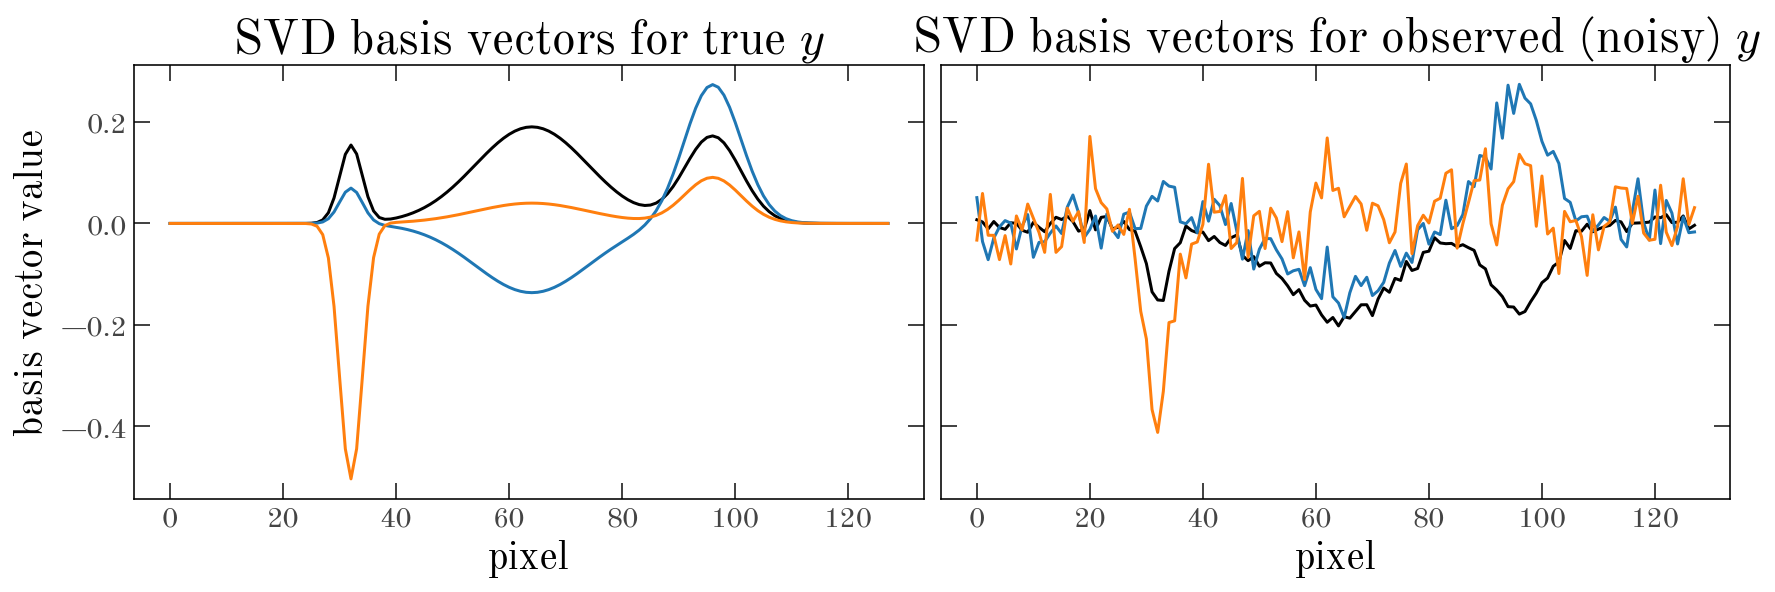

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), layout="constrained", sharex=True, sharey=True)
names = ["SVD basis vectors for true $y$", "SVD basis vectors for observed (noisy) $y$"]
axes[0].plot(
    pix,
    true_svd.Vh[:3].T,
    marker="",
)
axes[1].plot(
    pix,
    err_svd.Vh[:3].T,
    marker="",
)
for ax, name in zip(axes, names):
    _ = ax.set(
        xlabel="pixel",
        title=name,
    )
axes[0].set_ylabel("basis vector value")

### Limitations with an SVD (i.e. PCA) of noisy data

When data are high signal-to-noise and when you expect the underlying model to be close to linear, an SVD (or PCA) of your data can form a useful decomposition of the data. However, there are a number of limitations that motivate using a linear LVM for data instead:

1. If the uncertainties are heteroskedastic (i.e., differ by object or by element of the data): An SVD minimizes an unweighted squared error, which is only the right thing to do if every dimension of every object has the same noise properties. A spectrum with a bright sky line in one pixel or a survey with a mix of source brightness (and therefore signal-to-noise) violates this.
2. If data have missing values: Not every object is measured in every dimension. If you want to use SVD, you have to either infill missing data or limit your SVD to a subset of the sample with perfect coverage in the data, which is often not a representative sample of your full data set. SVDs have no natural way of handling missing values.
3. If there is more than one kind of observation: In the example above, we are considering a single mapping from latents to spectrum, but we often have other kinds of data that we might want to use simultaneously --- for example, we may have spectra, existing stellar labels, broadband photometry, and astrometry for the same sources. The different data outputs have different dimensionalities and dimensions, but might share a common latent representation.
4. If the relationship between the latents and the data is not linear: This is the case in our toy example, but doesn't have to be (as we explore later).

The first two (1 and 2) of these limitations are addressed by writing down a likelihood instead of a matrix norm, which is the step from PCA to probabilistic PCA. The 3rd point is addressed by letting the likelihood have several output blocks, each with its own function of the latents. The 4th point is addressed by allowing more complex mappings from latents to predicted outputs. Pollux implements and supports all four of these things with the LVM in {py:class}`~pollux.models.LVM`.

Let's see how we could implement a version of probabilistic PCA for the toy data we generated above using Pollux.

First, we wrap the data in a {py:class}`~pollux.data.PolluxData` instance:

In [50]:
data = plx.data.PolluxData(
    flux=plx.data.OutputData(y, err=y_err),
)

Then we construct the model and run an iterative optimization scheme to infer the latents and basis vectors (elements of $A$).

In [52]:
model = plx.LVM(latent_size=L)
model.register_output("flux", LinearTransform(output_size=D))

trained = model.optimize_iterative(
    data, max_cycles=64, rng_key=jax.random.PRNGKey(0), progress=False
)
trained_A = trained.params["flux"]["data"]["A"]

(Under the hood, by default, this assumes unit variance Normal priors on the latents and all elements of $A$ -- we customize these choices below.)

Let's look at the recovered _maximum a posteriori_ (MAP) basis vectors:

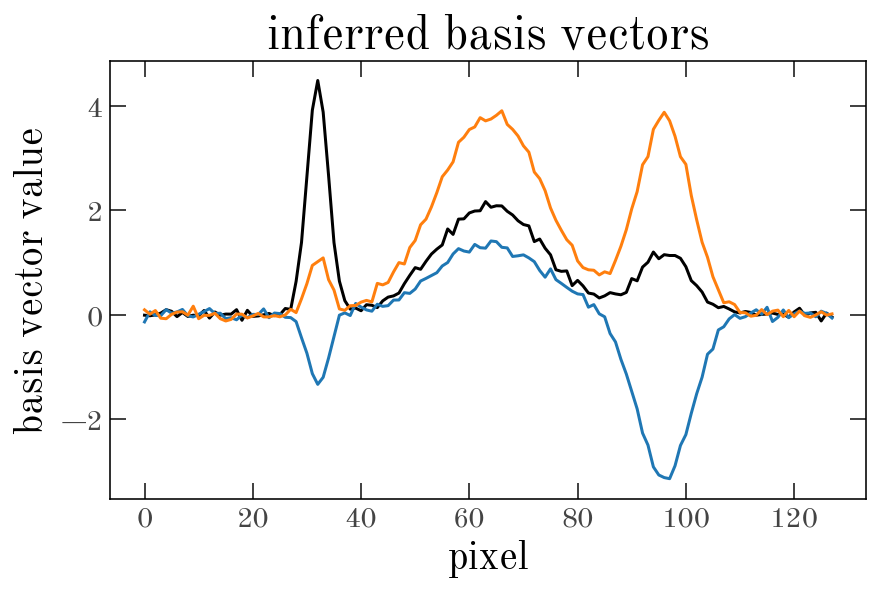

In [54]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.plot(trained_A, marker="")
_ = ax.set(xlabel="pixel", ylabel="basis vector value", title="inferred basis vectors")

(We could also connect this model to [numpyro](https://num.pyro.ai/) and run MCMC sampling to get posterior samples, but we won't demonstrate that here.)

The inferred basis vectors are much smoother, but since we know the ground truth here, we know that the inferred basis vectors are linear combinations of the true basis vectors. This is a known fact about PCA and probabilistic PCA: we can always rotate ($\mathrm{R}$) the basis vectors and inverse rotate ($\mathrm{R}^\top$) the latent vectors and get back the same mapping to predicted data:
$$ 
\mathrm{A} \, z_n = \left(\mathrm{A} \, \mathrm{R}^{-1}\right)\left(\mathrm{R} \, z_n\right) 
$$

For our example simulated data, we know that the data are generated such that the basis vectors are always positive and the coefficients are always negative (or vice versa). So instead of PCA or pPCA, we could use non-negative matrix factorization (NMF). NMF is like PCA, but with the additional constraints that:
$$
A_{ij} \geq 0 \\
z_{i} \geq 0
$$
for all elements of $A$ and $z$ (in our case, $z$ should be negative, and that is easy to handle in standard NMF).

In Pollux, we can enforce these constraints by using bounded priors on the elements of $\mathrm{A}$ and the latents $z$. Here we will create a second version of the model that uses unit variance Gaussians for both, but truncated to either be positive (for $A$) or to be negative (for $z$):

In [59]:
model_nmf = plx.LVM(latent_size=L)
latents_prior = dist.TruncatedNormal(scale=1.0, high=0.0)
model_nmf.register_output(
    "flux", LinearTransform(output_size=D, priors={"A": dist.HalfNormal(1.0)})
)

Now we optimize the model to get MAP values of $A$ and $z$ for this non-negative model:

In [60]:
trained_nmf = model_nmf.optimize_iterative(
    data,
    max_cycles=256,
    rng_key=jax.random.PRNGKey(0),
    progress=False,
    latents_prior=latents_prior
)
trained_nmf_A = trained_nmf.params["flux"]["data"]["A"]

TODO: now the original basis vectors are nearly recovered. This happens because we know the problem setup... 

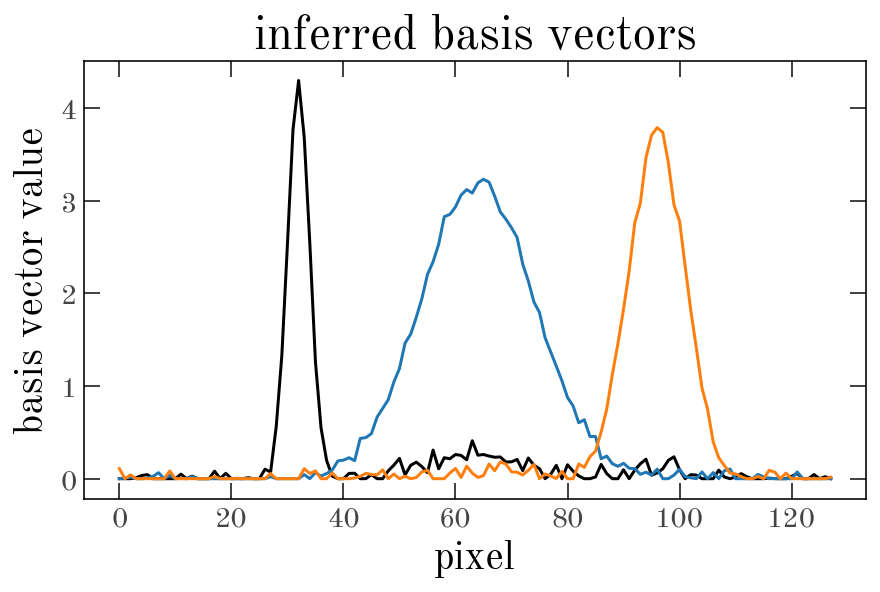

In [61]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.plot(trained_nmf_A, marker="")
_ = ax.set(xlabel="pixel", ylabel="basis vector value", title="inferred basis vectors")

## Latent Variable Models can be nonlinear

Either nonlinear in latents, or in function mapping latents to output data

TODO: example in literature - GPLVM from Eilers

## Latent Variable Models can have multiple outputs



TODO: refactor below here

says nothing about the functional form of the model, so let's pick the
simplest one that is useful. If we stack the observed data for all $N$ objects into a
matrix $Y$ with shape $(N, D)$ and the latents into a matrix $Z$ with shape $(N, L)$,
where $L \ll D$, then the linear version of the model above is

$$ Y \approx Z \, A^\top $$

where the coefficients $A$, with shape $(D, L)$, are shared by every object. Each row of
$Y$ is therefore a weighted sum of the $L$ columns of $A$ -- often called basis vectors,
or basis spectra in a spectroscopic context -- and the latents $z_n$ are the weights for
object $n$. This is the probabilistic PCA or factor analysis case mentioned above, and
when the noise is small and uniform you can find $A$ and $Z$ with a singular value
decomposition of $Y$.

To make this concrete, we will simulate data from exactly this model, using 512 objects
with a true latent dimensionality of 4, observed in 64 "flux" dimensions and 2 "label"
dimensions. If the model is a good description of the data, the singular values of $Y$
should tell us the latent dimensionality:

(One housekeeping note before we start: everywhere else in these tutorials you would
attach a preprocessor to rescale the data before fitting -- see
[Getting Started](LVM-getting-started.ipynb). We deliberately do not here, so that the
arrays in the code map one-to-one onto the symbols in the equations. The simulated data
are already well scaled, so nothing is lost by skipping it.)

The first four singular values sit well above the rest, and everything past them is the
noise we added. That cliff is the low-dimensional structure we were looking for, and for
data this clean we did not need anything more sophisticated than an SVD to find it.

## Where a singular value decomposition stops being enough

Real data are rarely this cooperative, and there are a few specific ways they break the
procedure above. Each one is a reason Pollux exists.

- The uncertainties differ from datum to datum. An SVD minimizes unweighted squared
  error, which is only the right thing to do if every dimension of every object has the
  same noise. A spectrum with a bright sky line in one pixel, or a survey with a mix of
  exposure times, badly violates this, and we would rather weight each residual by its
  own $1/\sigma^2$.
- Data go missing. Not every object is measured in every dimension, and an SVD has no
  notion of an absent entry.
- There is more than one kind of observation. We often do not just have spectra, but
  spectra *and* labels *and* photometry for the same objects, with different
  dimensionalities and different units. What ties them together is the belief that one
  latent vector per object generates all of them, whereas an SVD factors a single matrix.
- The relationship between the latents and the data need not be linear. $Y \approx Z
  A^\top$ is a modeling choice, not a law, and The Cannon (for example) wants a
  quadratic.

The first two of these are fixed by writing down a likelihood instead of a matrix norm,
which is the step from PCA to probabilistic PCA. The second two are fixed by letting that
likelihood have several output blocks, each with its own arbitrary function of the
latents. Doing all four at once is what the {py:class}`~pollux.models.LVM` class
implements.

## The model that Pollux implements

Every object gets a latent vector drawn from a prior. Each *output* of the model -- an
output being one block of observed data, like the fluxes or the labels -- is generated
from that latent vector by its own function, and is observed with Gaussian noise:

$$
z_n \sim p(z), \qquad
y^{(k)}_n \sim \mathcal{N}\!\left(f_k(z_n;\, \theta_k),\ \Sigma^{(k)}_n\right)
$$

Here $f_k$ is the function for output $k$ (in Pollux, its `data_transform`) and
$\theta_k$ are the coefficients that function depends on. The covariance is diagonal and
comes from applying the output's `err_transform` to the reported uncertainties. By
default that transform does nothing, so $\Sigma^{(k)}_n$ is just the reported
$(\sigma^{(k)}_n)^2$, but with a
{py:class}`~pollux.models.transforms.ScatterTransform` it becomes $\sigma^2 + s^2$ for a
fitted per-element scatter $s$.

This is the same PGM as before, with one $y$ node per output:

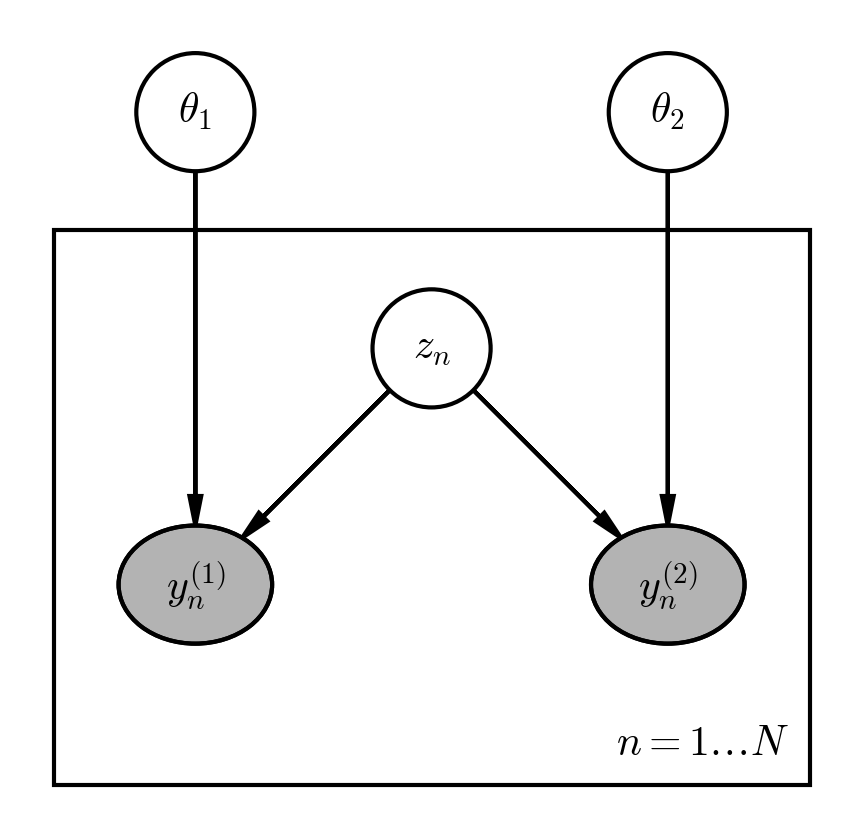

In [4]:
pgm = daft.PGM(observed_style="shaded", dpi=150)
pgm.add_node("theta1", r"$\theta_1$", 1, 3)
pgm.add_node("theta2", r"$\theta_2$", 3, 3)
pgm.add_node("z", r"$z_n$", 2, 2)
pgm.add_node("y1", r"$y^{(1)}_n$", 1, 1, observed=True, aspect=1.3)
pgm.add_node("y2", r"$y^{(2)}_n$", 3, 1, observed=True, aspect=1.3)
for parent, child in [("z", "y1"), ("z", "y2"), ("theta1", "y1"), ("theta2", "y2")]:
    pgm.add_edge(parent, child)
pgm.add_plate(
    [0.4, 0.15, 3.2, 2.35],
    label=r"$n = 1 \ldots N$",
    shift=0.0,
    position="bottom right",
)
pgm.render();

Both outputs hang off the same $z_n$, and that is the whole point: it is what allows a
model trained on objects that have both kinds of data to say something about an object
that has only one of them. Note also where things sit relative to the plate. The latents
are inside it, one per object, and the coefficients are outside it, shared by all of
them, exactly as in the general PGM at the top of this note.

### What is actually being optimized

The {py:meth}`~pollux.models.LVM.optimize` method runs stochastic variational inference
with an `AutoDelta` guide, which is a roundabout way of saying that it finds the
*maximum a posteriori* (MAP) parameter values. It minimizes the negative log posterior
over the latents and the coefficients jointly:

$$
-\ln p = \sum_{n}\sum_{k}\sum_{d}
\left[
\frac{\left(y^{(k)}_{nd} - f_k(z_n;\theta_k)_d\right)^2}{2\,\Sigma^{(k)}_{nd}}
+ \tfrac{1}{2}\ln \Sigma^{(k)}_{nd}
\right]
- \sum_n \ln p(z_n) - \sum_k \ln p(\theta_k)
$$

There are three things worth pointing out here. The first term is a $\chi^2$, so this is
a weighted fit: that is the fix for heteroscedastic uncertainties, and it is also how
missing data are handled, since a datum given an enormous error bar contributes
essentially nothing to the sum (which is exactly the trick used in the
[missing labels](LVM-hierarchical-missing-labels.ipynb) tutorial). The second term,
$\ln \Sigma$, does nothing at all when the uncertainties are fixed, but it becomes
important the moment you fit a scatter $s$: without it, the optimizer would happily
inflate $s$ until every residual was excused and the $\chi^2$ vanished. The last two
terms are the priors, and they act as regularization -- the prior on $\theta$ in
particular is where you control how strongly the coefficients are shrunk toward zero.

To make sure the forward model is what it claims to be, we can build the two-output
linear model described above and check it against the matrix multiplication by hand:

In [ ]:
model = plx.LVM(latent_size=L)
model.register_output("label", LinearTransform(output_size=n_labels))
model.register_output("flux", LinearTransform(output_size=n_flux))

# evaluate the forward model at the parameters that generated the data
z = jnp.asarray(truth["latents"])
pars = {
    "latents": z,
    "label": {"data": {"A": jnp.asarray(truth["A"])}, "err": {}},
    "flux": {"data": {"A": jnp.asarray(truth["B"])}, "err": {}},
}

predicted = model.predict_outputs(pars)["flux"]
by_hand = z @ jnp.asarray(truth["B"]).T

print(
    "predict_outputs matches Z A^T:", bool(jnp.allclose(predicted, by_hand, atol=1e-4))
)
print("shapes:", predicted.shape, "= (n_stars, n_flux)")

predict_outputs matches Z A^T: True
shapes: (512, 64) = (n_stars, n_flux)


## The latents and the coefficients

The distinction we drew at the top of this note -- between the per-object latents and the
coefficients shared across objects -- is worth returning to, because it is not just
terminology. It determines what you can do with a fitted model.

The latents describe the objects you happened to observe. There are $N \times L$ of them
and that number grows with your dataset, so they are not something you can carry to a new
object. The coefficients describe the *relationship* between the latent space and the
observables, their size is set by the model architecture rather than by $N$, and they are
precisely the part of a fitted model that transfers.

Pollux does not take your word for which parameters are which. It works it out by
expanding each transform's priors at two different dataset sizes and seeing which
parameter shapes change:

In [6]:
carried = model.output_pars(pars)

print("latents, tied to the objects we fitted:", sorted(model.per_object_param_names()))
print(
    "coefficients, carried to new objects:  ", sorted(model.pack_numpyro_pars(carried))
)

latents, tied to the objects we fitted: ['latents']
coefficients, carried to new objects:   ['flux:A', 'label:A']


### Training a model, then applying it

This split is what makes label transfer work. You fit everything -- latents and
coefficients -- on a training set of objects that have both spectra and labels. Then, for
an object with only a spectrum, you hold the coefficients fixed at their trained values
and optimize only that object's latent vector. The label output can then be evaluated for
that object even though it never saw a label for it.

In Pollux, {py:meth}`~pollux.models.LVM.output_pars` selects the coefficients out of a
fitted parameter dictionary for you, and passing `blocks=["latents"]` says to optimize
nothing else:

In [7]:
train = plx.data.PolluxData(
    label=plx.data.OutputData(obs["label"][:256], err=obs["label_err"][:256]),
    flux=plx.data.OutputData(obs["flux"][:256], err=obs["flux_err"][:256]),
)
# the test objects have a spectrum and nothing else
test_flux_only = plx.data.PolluxData(
    flux=plx.data.OutputData(obs["flux"][256:], err=obs["flux_err"][256:])
)

trained = model.optimize_iterative(
    train, max_cycles=50, rng_key=jax.random.PRNGKey(0), progress=False
)
applied = model.optimize_iterative(
    test_flux_only,
    blocks=["latents"],
    fixed_pars=model.output_pars(trained.params),
    progress=False,
)

inferred = model.predict_outputs(applied.params, names="label")["label"]
rmse = np.sqrt(np.mean((inferred - obs["label"][256:]) ** 2, axis=0))
print("label RMSE from the spectrum alone:", np.round(rmse, 4))
print(
    "typical label uncertainty:         ",
    np.round(obs["label_err"][256:].mean(axis=0), 4),
)

label RMSE from the spectrum alone: [0.0619 0.0616]
typical label uncertainty:          [0.0549 0.0565]


The labels recovered from the spectra alone are about as good as the reported label
uncertainties, which is roughly the best we could hope for given the data we simulated.

## Lux and The Cannon

Pollux ships two named model architectures for stellar spectroscopy, and neither is a
separate framework: each is a particular choice of the functions $f_k$ in the model
above, and both are ordinary {py:class}`~pollux.models.LVM` instances.

{py:class}`~pollux.models.Lux` takes both outputs to be linear in the latents, which is
the model we have been using throughout this note. The latent vector is genuinely latent:
it is inferred rather than measured, and it is usually chosen to be larger than the number
of labels but much smaller than the number of spectral pixels.

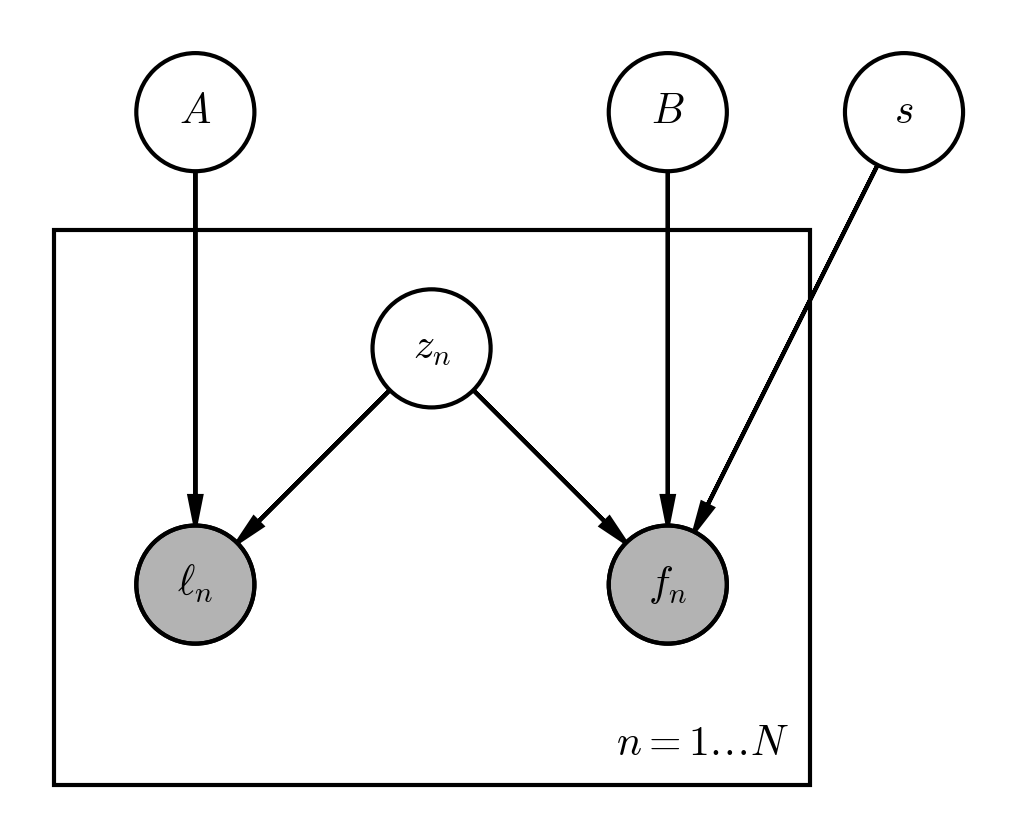

In [8]:
pgm = daft.PGM(observed_style="shaded", dpi=150)
pgm.add_node("A", r"$A$", 1, 3)
pgm.add_node("B", r"$B$", 3, 3)
pgm.add_node("s", r"$s$", 4, 3)
pgm.add_node("z", r"$z_n$", 2, 2)
pgm.add_node("label", r"$\ell_n$", 1, 1, observed=True)
pgm.add_node("flux", r"$f_n$", 3, 1, observed=True)
for parent, child in [
    ("z", "label"),
    ("z", "flux"),
    ("A", "label"),
    ("B", "flux"),
    ("s", "flux"),
]:
    pgm.add_edge(parent, child)
pgm.add_plate(
    [0.4, 0.15, 3.2, 2.35],
    label=r"$n = 1 \ldots N$",
    shift=0.0,
    position="bottom right",
)
pgm.render();

{py:class}`~pollux.models.Cannon` makes a different choice: the latent vector *is* the
vector of stellar labels. There is no separate embedding to discover, because the thing
playing the role of the latents is measured for the training objects. In Pollux this is
expressed by registering the labels as an output with a
{py:class}`~pollux.models.transforms.NoOpTransform`, so that the latents are observed
directly. The spectrum is then a quadratic function of the labels: a polynomial feature
expansion followed by a linear map.

The only thing that changes in the PGM is that the middle node is now shaded:

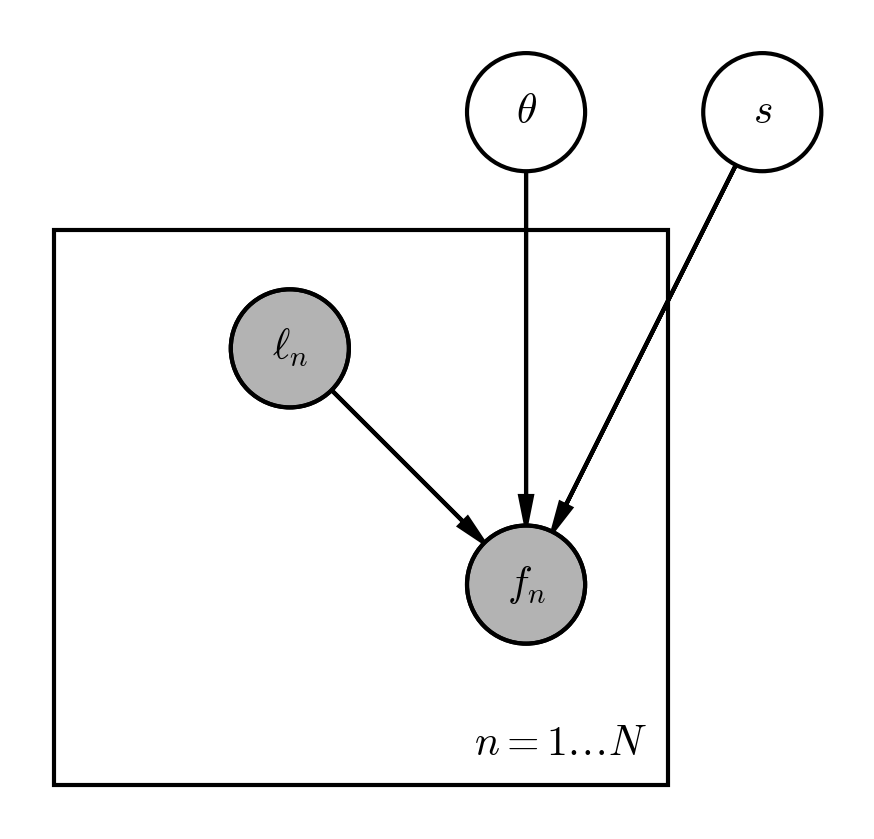

In [9]:
pgm = daft.PGM(observed_style="shaded", dpi=150)
pgm.add_node("theta", r"$\theta$", 3, 3)
pgm.add_node("s", r"$s$", 4, 3)
pgm.add_node("label", r"$\ell_n$", 2, 2, observed=True)
pgm.add_node("flux", r"$f_n$", 3, 1, observed=True)
for parent, child in [("label", "flux"), ("theta", "flux"), ("s", "flux")]:
    pgm.add_edge(parent, child)
pgm.add_plate(
    [1.0, 0.15, 2.6, 2.35],
    label=r"$n = 1 \ldots N$",
    shift=0.0,
    position="bottom right",
)
pgm.render();

That single difference in shading is essentially the whole distinction between the two
models, and it explains a lot about how they behave. Because The Cannon's latents are
pinned to measured labels during training, fitting its coefficients is a clean linear
problem with a single solution. Because Lux's latents are free, it can make use of
directions in the data that no label describes, but it has correspondingly more to
determine from the same observations.

At test time The Cannon's label node becomes unshaded, and inferring labels from a
spectrum is the same "hold the coefficients fixed and optimize the latents" operation we
did above.

Both architectures are just `LVM` instances with outputs already registered, and you can
see the difference in the transforms they use:

In [10]:
lux = plx.Lux(latent_size=16, label_size=n_labels, flux_size=n_flux)
cannon = plx.Cannon(label_size=n_labels, output_size=n_flux)

for name, m in [("Lux", lux), ("Cannon", cannon)]:
    print(f"{name} (latent_size={m.latent_size}):")
    for output, spec in m.outputs.items():
        transform = spec.data_transform
        inner = getattr(transform, "transforms", None)
        described = (
            " -> ".join(type(t).__name__ for t in inner)
            if inner
            else type(transform).__name__
        )
        print(f"    {output:6s}: {described}")

Lux (latent_size=16):
    label : LinearTransform
    flux  : LinearTransform
Cannon (latent_size=2):
    label : NoOpTransform
    flux  : PolyFeatureTransform -> LinearTransform


## Linear and nonlinear models

The difference between Lux and The Cannon above is really a difference in whether $f_k$
is linear in the latents, and that distinction has consequences worth being explicit
about.

A model like Lux is *bilinear*: the predictions are linear in the latents at fixed
coefficients, and linear in the coefficients at fixed latents. The objective is therefore
not convex in both at once, but it is exactly quadratic in either one on its own, which
means each of those sub-problems has a closed-form least squares solution. This is what
{py:meth}`~pollux.models.LVM.optimize_iterative` exploits when it cycles between blocks
of parameters, and the
[Linearized, closed-form solves](../linear-solves.md) note describes how Pollux works out
which sub-problems qualify. Two other conveniences follow from linearity: there are no
local optima to worry about within a block, and the uncertainties we discuss at the end of
this note are exact rather than approximate.

The Cannon is linear in its coefficients but quadratic in its labels, so only half of
that holds. Fitting the coefficients at fixed labels is still a linear solve, and it is
why training The Cannon is so fast. Inferring labels from a spectrum, though, is a
genuinely nonlinear optimization: there can be more than one local optimum, the starting
point matters, and Pollux will tell you it has fallen back on gradient descent for that
block rather than solving it exactly.

## The latents are not unique

Here is a result that catches people out. Take any invertible $L \times L$ matrix $R$ and
rewrite the linear model:

$$ A \, z_n = \left(A R^{-1}\right)\left(R\, z_n\right) $$

If we rotate every latent vector by $R$ and the coefficient matrix by $R^{-1}$, every
prediction the model makes is unchanged. The likelihood cannot distinguish the two
because they are the same function. You might hope the prior would break the tie, but it
does not: the default $\mathcal{N}(0, 1)$ prior on the latents is isotropic, so it is
invariant under rotations as well, and its contribution $\sum_n \lVert z_n \rVert^2$ is
identical before and after.

In [11]:
R = jnp.linalg.qr(jax.random.normal(jax.random.PRNGKey(3), (n_latents, n_latents)))[0]

rotated = {
    "latents": z @ R.T,
    "flux": {"data": {"A": pars["flux"]["data"]["A"] @ jnp.linalg.inv(R)}, "err": {}},
}

before = model.predict_outputs(pars, names="flux")["flux"]
after = model.predict_outputs(rotated, names="flux")["flux"]

print("predictions identical:  ", bool(jnp.allclose(before, after, atol=1e-4)))
print("prior term before/after:", float(jnp.sum(z**2)), float(jnp.sum((z @ R.T) ** 2)))

predictions identical:   True
prior term before/after: 2055.67626953125 2055.67626953125


A fit therefore does not recover *the* latent basis, because there is no such thing to
recover. What it does determine is the *subspace* that those basis vectors span. Since we
simulated this dataset ourselves we can check that directly: compare the column space of
the fitted coefficient matrix against the column space of the one that generated the
fluxes. The comparison has to be made with something that depends only on the subspace
and not on the particular basis, and the projection matrix onto each column space is
exactly that.

In [12]:
# The projection matrix onto the column space of M depends only on the subspace,
# unlike M itself, so it is the thing worth comparing.
def projector(M):
    Q, _ = jnp.linalg.qr(M)
    return Q @ Q.T


A_fit = trained.params["flux"]["data"]["A"]
B_true = jnp.asarray(truth["B"])
random_matrix = jax.random.normal(jax.random.PRNGKey(1), (n_flux, n_latents))

print("max |A_fit - B_true|, elementwise:", float(jnp.abs(A_fit - B_true).max()))
print()
print(
    "subspace distance ||P_fit - P_true||:",
    float(jnp.linalg.norm(projector(A_fit) - projector(B_true))),
)
print(
    "...for an unrelated random matrix:  ",
    float(jnp.linalg.norm(projector(random_matrix) - projector(B_true))),
)

max |A_fit - B_true|, elementwise: 5.880927085876465

subspace distance ||P_fit - P_true||: 0.006471224594861269
...for an unrelated random matrix:   2.729578733444214


So the fitted coefficients are nowhere near the true ones entry by entry, and yet they
span essentially the same subspace. Both of those statements are true, and only the
second one is meaningful.

The practical consequence is that you should not try to interpret individual latent
dimensions. A statement like "latent 3 is the temperature direction" is not something the
model supports, and if you refit from a different starting point latent 3 will be
something else entirely. Questions about the latent space as a whole -- how many
dimensions the data actually support, what some direction within it predicts, whether two
objects are close to each other -- are perfectly well posed, and those are the questions
worth asking.

## What you get from a MAP fit

Because `AutoDelta` returns the mode of the posterior rather than samples from it, there
is no posterior width on the coefficients at all. The per-object uncertainties available
from {py:meth}`~pollux.models.LVM.latent_uncertainties` come from the curvature of the
objective at that mode:

$$ \mathrm{Cov}(z_n) \approx \left[ \nabla^2_{z_n} \left(-\ln p\right) \right]^{-1} $$

Since the coefficients are held fixed at their fitted values while this is computed,
these uncertainties are *conditional* on the coefficients being correct -- an empirical
Bayes step. With a large training set that is a fairly mild assumption, but with a small
one it is not, and the resulting error bars will be too small.

In [13]:
sigma_z = model.latent_uncertainties(test_flux_only, applied.params, names="flux")

print("shape:", sigma_z.shape, "= (n_test, latent_size)")
print("median per-dimension uncertainty:", np.round(np.median(sigma_z, axis=0), 4))

shape: (256, 4) = (n_test, latent_size)
median per-dimension uncertainty: [0.0033 0.0028 0.0026 0.0031]


One more caveat is worth stating plainly, and it connects back to the linear/nonlinear
distinction above. This is the curvature *at a minimum*. For a model that is linear in
the latents the objective is exactly quadratic, so these are the exact conditional widths.
For a nonlinear one such as The Cannon it is a local approximation, and away from a true
minimum the Hessian can fail to be positive definite altogether -- in which case Pollux
returns `nan` rather than a reassuringly small number.

## Where to go next

- [Getting Started](LVM-getting-started.ipynb) walks through the same model hands on,
  including the preprocessing step we skipped here.
- [Iterative optimization](LVM-iterative-optimization.ipynb) and
  [Linearized, closed-form solves](../linear-solves.md) cover how the fit exploits the
  bilinear structure discussed above.
- [Error models](LVM-error-models.ipynb) is about fitting the scatter $s$, and the
  $\ln \Sigma$ term earning its keep.
- [Missing labels](LVM-hierarchical-missing-labels.ipynb) uses the enormous-error-bar
  trick for absent data.